# Ensemble

Here i will combine two models a Random Forest and a Neural Network to try to stack them for a better result

## First start with some helper functions

In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score
from torch import nn
from tqdm.auto import tqdm
from torch.utils.data import TensorDataset, DataLoader
from itertools import product
from sklearn.ensemble import RandomForestClassifier

In [241]:
def transfrom_data(data):
    data = data.drop(["Name", "Cabin", "Ticket", "PassengerId"], axis=1)

    data["Sex"] = data["Sex"].map({"male":0, "female":1})
    data["Embarked"] = data["Embarked"].map({"S": 0, "C":1, "Q": 2})

    data["Age"] = data["Age"].fillna(data["Age"].mean())
    data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mean())

    return data

def process_file(train_path: str,
                 val_path: str,
                 to_tensor: bool):
    train_data = pd.read_csv(train_path)
    val_data = pd.read_csv(val_path)

    train_data = transfrom_data(train_data)
    val_data = transfrom_data(val_data)

    X, y = train_data.drop(columns=["Survived"]), train_data["Survived"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=52)

    scalar = StandardScaler()
    scalar.fit(X_train)

    X_train = pd.DataFrame(
        scalar.transform(X_train),
        columns=X_train.columns,
        index = X_train.index
    )
    X_test = pd.DataFrame(
        scalar.transform(X_test),
        columns=X_test.columns,
        index = X_test.index
    )
    X_val = pd.DataFrame(
        scalar.transform(val_data),
        columns=val_data.columns,
        index = val_data.index
    )
    if to_tensor:
        return torch.tensor(X_train.values), torch.tensor(X_test.values), torch.tensor(y_train.values), torch.tensor(y_test.values), torch.tensor(X_val.values)    
    return X_train, X_test, y_train, y_test, X_val

def evaluate_model(y_pred, y_test):
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
    print(classification_report(y_test, y_pred))

def feauture_importance(rf, X):
    feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
    feature_importances = feature_importances.sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    plt.bar(feature_importances.index, feature_importances.values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Feature Importance")
    plt.title("Random Forest Feature Importances")
    plt.show()

def write_results(write_to_path: str,
                  test_path: str,
                  y_pred):
    id = pd.read_csv(test_path)["PassengerId"]
    df = pd.DataFrame({
        "PassengerId": id,
        "Survived": y_pred
    })

    df.to_csv(write_to_path, index=False)

## Now we move onto the Neural network

In [14]:
class NeuralModel(nn.Module):
    def __init__(self,
                 input_units: int,
                 hidden_units: int,
                 output_units: int,
                 num_hidden_layers: int):
        super().__init__()

        layers = []
        layers.append(nn.Linear(input_units, hidden_units))
        layers.append(nn.ReLU())

        for i in range(num_hidden_layers):
            layers.append(nn.Linear(hidden_units, hidden_units))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(hidden_units, output_units))

        self.layer_stack = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.layer_stack(x)

In [26]:
def train_test_model(model: nn.Module,
                     epochs: int,
                     batch_size: int,
                     optimizer,
                     X_train, X_test,
                     y_train, y_test,
                     print_interval: int = 10,
                     print: bool=False):
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    train_dataloader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )
    test_dataloader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )
    
    loss_fn = nn.BCEWithLogitsLoss()

    for epoch in tqdm(range(epochs)):
        train_loss = 0
        train_acc = 0

        model.train()
        for X, y in train_dataloader:
            y_logit = model(X)
            y_pred = torch.round(torch.sigmoid(y_logit))

            optimizer.zero_grad()

            loss = loss_fn(y_logit, y)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()
            train_acc += (y_pred == y).sum().item() / len(y_pred)
        
        train_acc /= len(train_dataloader)
        train_loss /= len(train_dataloader)

        test_loss = 0
        test_acc = 0

        model.eval()
        for X, y in test_dataloader:
            with torch.inference_mode():
                y_logit = model(X)
                y_pred = torch.round(torch.sigmoid(y_logit))

                loss = loss_fn(y_logit, y)
            
            test_loss += loss
            test_acc += (y_pred == y).sum().item() / len(y_pred)

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

        if (epoch == epochs - 1 or epoch % print_interval == 0) and print:
            print(f"Epoch: {epoch} | Train: {train_loss:.6f} loss, {train_acc:.6f}% | Test: {test_loss:.6f} loss, {test_acc:.6f}% |")

In [27]:
param_grid = {
    "lr": [0.1, 0.01, 0.001],
    "hidden_units": [5, 10, 32, 64],
    "num_layers": [1, 3, 5],
    "epochs": [10, 50, 100],
    "batch_size": [8, 32, 64],
    "optimizer": [torch.optim.SGD, torch.optim.Adam]
}

all_combinations = list(product(
    param_grid["lr"],
    param_grid["hidden_units"],
    param_grid["num_layers"],
    param_grid["epochs"],
    param_grid["batch_size"],
    param_grid["optimizer"]
))

In [28]:
X_train_nn, X_test_nn, y_train_nn, y_test_nn, X_val_nn =  process_file("train.csv", "test.csv", True)
X_train_nn, X_test_nn, y_train_nn, y_test_nn = X_train_nn.float(), X_test_nn.float(), y_train_nn.float(), y_test_nn.float()

y_train_nn = y_train_nn.unsqueeze(1)
y_test_nn = y_test_nn.unsqueeze(1)

results = []

for lr, hidden_units, num_layers, epochs, batch_size, optimizer_class in all_combinations:
    model = NeuralModel(input_units=len(X_train_nn[0]),
                        hidden_units=hidden_units,
                        output_units=1,
                        num_hidden_layers=num_layers)
    
    train_test_model(model=model,
                     epochs=epochs,
                     batch_size=batch_size,
                     optimizer=optimizer_class(params=model.parameters(),
                                               lr = lr),
                     X_train=X_train_nn, X_test=X_test_nn,
                     y_train=y_train_nn, y_test = y_test_nn,
                     print_interval=epochs//10)
    
    # Evaluate the model
    y_logit = model(X_test_nn)
    y_pred = torch.round(torch.sigmoid(y_logit))

    acc = (y_pred == y_test_nn).sum().item() / len(y_pred)

    results.append({"lr": lr,
                    "hidden_units": hidden_units,
                    "num_layers": num_layers,
                    "epochs": epochs,
                    "batch_size": batch_size,
                    "optimizer_class": optimizer_class,
                    "accuracy_score": acc})
    

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="accuracy_score", ascending=False)

df_results

100%|██████████| 100/100 [00:02<00:00, 37.52it/s]


,lr,hidden_units,num_layers,epochs,batch_size,optimizer_class,accuracy_score
513,0.001,10,3,50,32,<class 'torch.optim.adam.Adam'>,0.798883
479,0.001,5,5,50,64,<class 'torch.optim.adam.Adam'>,0.798883
237,0.010,5,3,10,32,<class 'torch.optim.adam.Adam'>,0.798883
41,0.100,5,5,10,64,<class 'torch.optim.adam.Adam'>,0.793296
647,0.001,64,5,100,64,<class 'torch.optim.adam.Adam'>,0.793296
...,...,...,...,...,...,...,...
478,0.001,5,5,50,64,<class 'torch.optim.sgd.SGD'>,0.407821
436,0.001,5,1,10,64,<class 'torch.optim.sgd.SGD'>,0.407821
452,0.001,5,3,10,32,<class 'torch.optim.sgd.SGD'>,0.407821
504,0.001,10,3,10,8,<class 'torch.optim.sgd.SGD'>,0.363128


In [244]:
X_train_nn, X_test_nn, y_train_nn, y_test_nn, X_val_nn =  process_file("train.csv", "test.csv", True)
X_train_nn, X_test_nn, y_train_nn, y_test_nn = X_train_nn.float(), X_test_nn.float(), y_train_nn.float(), y_test_nn.float()

y_train_nn = y_train_nn.unsqueeze(1)
y_test_nn  = y_test_nn.unsqueeze(1)

best_values = df_results.iloc[0]

print(best_values)

nn_model = NeuralModel(input_units=len(X_train_nn[0]),
                       hidden_units=best_values["hidden_units"],
                       output_units=1,
                       num_hidden_layers=best_values["num_layers"])

train_test_model(model=nn_model,
                 epochs=best_values["epochs"],
                 batch_size=best_values["batch_size"].item(),
                 optimizer=best_values["optimizer_class"](params=nn_model.parameters(),
                                                          lr=best_values["lr"]),
                 X_train=X_train_nn, X_test=X_test_nn,
                 y_train=y_train_nn, y_test=y_test_nn,
                 print_interval=10)

lr                                           0.001
hidden_units                                    10
num_layers                                       3
epochs                                          50
batch_size                                      32
optimizer_class    <class 'torch.optim.adam.Adam'>
accuracy_score                            0.798883
Name: 513, dtype: object


100%|██████████| 50/50 [00:01<00:00, 27.07it/s]


In [245]:
X_val_nn = X_val_nn.float()

nn_model.eval()
with torch.inference_mode():
    y_logit_nn = nn_model(X_val_nn)
    y_pred_nn = torch.round(torch.sigmoid(y_logit_nn))
    y_pred_nn = y_pred_nn.squeeze().int()

    write_results(write_to_path="resutls_only_nn.csv", test_path="test.csv", y_pred=y_pred_nn.numpy())

## Now we move onto Random Forest

Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       113
           1       0.76      0.73      0.74        66

    accuracy                           0.82       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



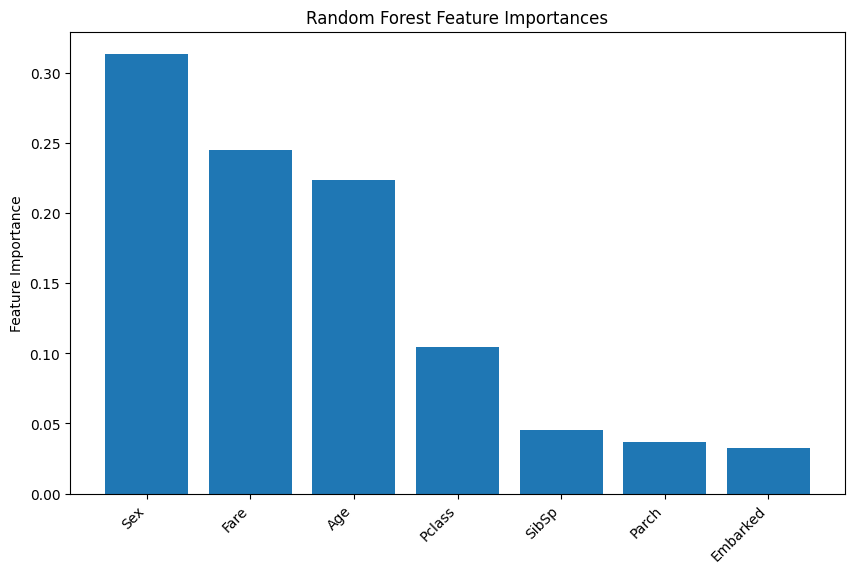

In [246]:
rf_model = RandomForestClassifier()

X_train, X_test, y_train, y_test, X_val = process_file("train.csv",
                                                       "test.csv",
                                                       False)

params_grid = {
    "n_estimators": [50, 100, 200, 500, 1000],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 4, 10],
    "max_features": ["sqrt", "log2", 0.5]
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=params_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

y_pred_rf_test = best_rf.predict(X_test)

evaluate_model(y_pred_rf_test, y_test)
feauture_importance(best_rf, X_train)

## And now we combine them

In [247]:
y_pred_rf = best_rf.predict(X_val)

corr = torch.corrcoef(torch.cat([torch.tensor(y_pred_rf).float().unsqueeze(1), y_pred_nn.float().unsqueeze(1)], dim=1).T)
print(corr)

tensor([[1.0000, 0.0331],
        [0.0331, 1.0000]])


In [ ]:
class CombineModelsModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(2, 1)

    def forward(self, x):
        return self.layer(x)


from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_rf_proba = np.zeros(len(X_all))
oof_nn_logit = np.zeros(len(X_all))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_all_scaled)):
    print(f"Fold {fold+1}/5")
    X_tr, X_val_fold = X_all_scaled[train_idx], X_all_scaled[val_idx]
    y_tr, y_val_fold = y_all[train_idx],         y_all[val_idx]

    # RF
    rf_fold = RandomForestClassifier(**BEST_RF_PARAMS)
    rf_fold.fit(X_tr, y_tr)
    oof_rf_proba[val_idx] = rf_fold.predict_proba(X_val_fold)[:, 1]

    # NN
    X_tr_t  = torch.tensor(X_tr,       dtype=torch.float32)
    X_val_t = torch.tensor(X_val_fold, dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,       dtype=torch.float32).unsqueeze(1)
    y_val_t = torch.tensor(y_val_fold, dtype=torch.float32).unsqueeze(1)

    nn_model = NeuralModel(input_units=X_tr_t.shape[1],
                           hidden_units=10,
                           output_units=1,
                           num_hidden_layers=3)

    train_test_model(model=nn_model,
                     epochs=50,
                     batch_size=32,
                     optimizer=torch.optim.Adam(nn_model.parameters(), lr=0.001),
                     X_train=X_tr_t, X_test=X_val_t,
                     y_train=y_tr_t, y_test=y_val_t)

    nn_model.eval()
    with torch.inference_mode():
        oof_nn_logit[val_idx] = nn_model(X_val_t).squeeze().numpy()

# ── Meta-learner inputs ───────────────────────────────────────────────
rf_oof_logit = torch.logit(
    torch.tensor(oof_rf_proba, dtype=torch.float32).unsqueeze(1).clamp(1e-6, 1 - 1e-6)
)
nn_oof_logit  = torch.tensor(oof_nn_logit, dtype=torch.float32).unsqueeze(1)
y_all_t       = torch.tensor(y_all,        dtype=torch.float32).unsqueeze(1)
combine_input = torch.cat([rf_oof_logit, nn_oof_logit], dim=1)

# ── Train meta-learner ────────────────────────────────────────────────
combine_model = CombineModelsModel()
with torch.no_grad():
    combine_model.layer.weight.fill_(1.0)
    combine_model.layer.bias.fill_(0.0)

optimizer = torch.optim.Adam(combine_model.parameters(), lr=0.001)
loss_fn   = nn.BCEWithLogitsLoss()

for epoch in range(300):
    combine_model.train()
    optimizer.zero_grad()
    y_pred = combine_model(combine_input)
    loss   = loss_fn(y_pred, y_all_t)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0 or epoch == 299:
        acc = (torch.round(torch.sigmoid(y_pred)) == y_all_t).float().mean().item()
        print(f"Epoch {epoch:3d} | loss: {loss:.4f}, acc: {acc:.4f}")

# ── Retrain base models on ALL data ──────────────────────────────────
best_rf.fit(X_all_scaled, y_all)

X_all_t  = torch.tensor(X_all_scaled, dtype=torch.float32)
y_all_t2 = torch.tensor(y_all,        dtype=torch.float32).unsqueeze(1)

final_nn = NeuralModel(input_units=X_all_t.shape[1],
                       hidden_units=10,
                       output_units=1,
                       num_hidden_layers=3)

train_test_model(model=final_nn,
                 epochs=50,
                 batch_size=32,
                 optimizer=torch.optim.Adam(final_nn.parameters(), lr=0.001),
                 X_train=X_all_t, X_test=X_all_t,
                 y_train=y_all_t2, y_test=y_all_t2)

# ── Predict on Kaggle test set ────────────────────────────────────────
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)

final_nn.eval()
with torch.inference_mode():
    nn_val_logit = final_nn(X_val_t).detach()

rf_val_logit = torch.logit(
    torch.tensor(best_rf.predict_proba(X_val_scaled)[:, 1],
                 dtype=torch.float32).unsqueeze(1).clamp(1e-6, 1 - 1e-6)
)

combine_val = torch.cat([rf_val_logit, nn_val_logit], dim=1)

combine_model.eval()
with torch.inference_mode():
    y_pred_val = torch.round(torch.sigmoid(combine_model(combine_val))).squeeze().int()

write_results("results_ensemble.csv", "test.csv", y_pred_val.numpy())

Fold 1/5


AttributeError: 'NeuralModel' object has no attribute 'BCEWithLogitsLoss'